<a href="https://colab.research.google.com/github/thickiana/titanic/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




In [7]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
df_as=df[["Survived","Parch"]]
df_as.head()


,Survived,Parch
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0


In [ ]:
df_as.nunique()

,0
Survived,2
Parch,7


In [ ]:
df_as.groupby("Survived").count()

,Parch
Survived,
0,549
1,342


Text(0.5, 1.0, 'number of parch')

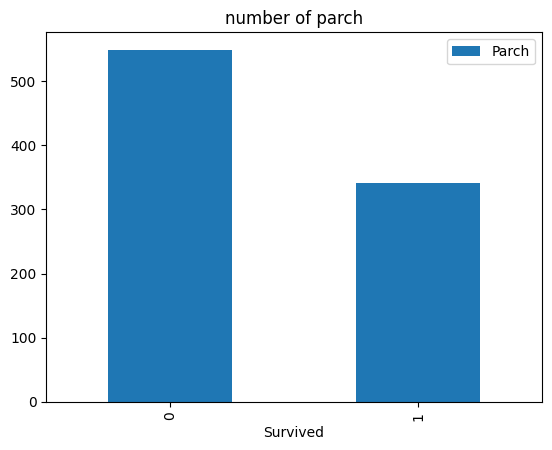

In [ ]:
df_as.groupby("Survived").count().plot(kind="bar");plt.title("number of parch")

In [ ]:
df_as.groupby("Parch").count()

,Survived
Parch,
0,678
1,118
2,80
3,5
4,4
5,5
6,1


Text(0.5, 1.0, 'number of parch')

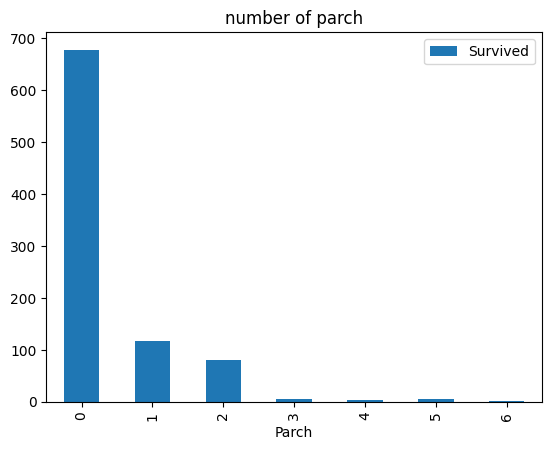

In [ ]:
df_as.groupby("Parch").count().plot(kind="bar");plt.title("number of parch")

In [ ]:
df_as.Parch.value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [ ]:
df_as.describe()

,Survived,Parch
count,891.000000,891.000000
mean,0.383838,0.381594
std,0.486592,0.806057
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,1.000000,6.000000


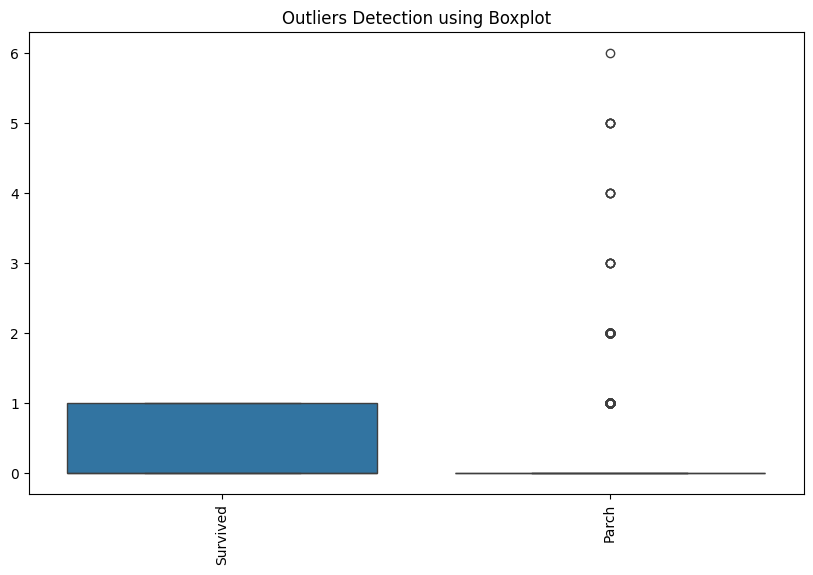

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_as.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outliers Detection using Boxplot")
plt.show()

Text(0.5, 1.0, 'number of parch vs survived')

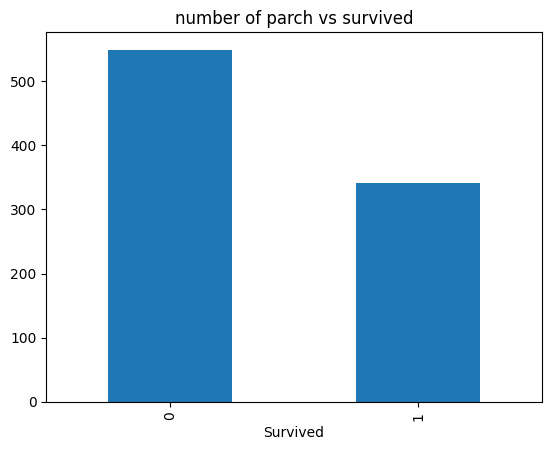

In [ ]:
df.groupby("Survived").count()["Parch"].plot(kind="bar");plt.title("number of parch vs survived")

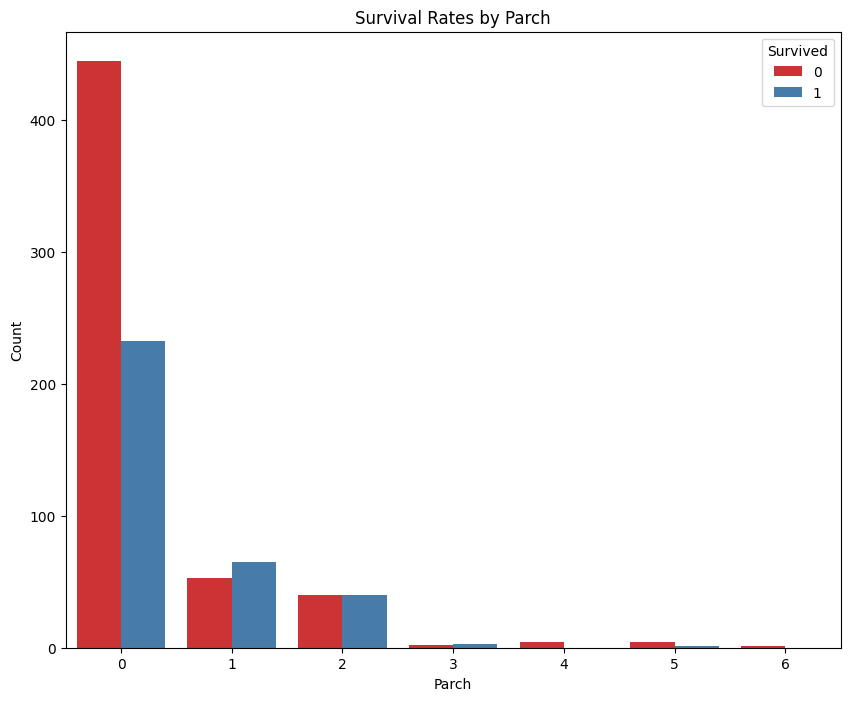

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Parch', hue='Survived', data=df, palette='Set1')
plt.title('Survival Rates by Parch')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.legend(title='Survived', loc='upper right')
plt.show()

In [ ]:
df_as.corr()

,Survived,Parch
Survived,1.000000,0.081629
Parch,0.081629,1.000000


Correlation between Survived and Parch: 0.08162940708348371


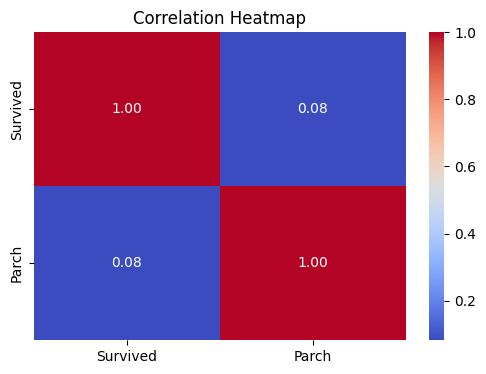

In [ ]:
correlation = df_as['Survived'].corr(df_as['Parch'])
print(f"Correlation between Survived and Parch: {correlation}")

# Visualize the correlation using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_as.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

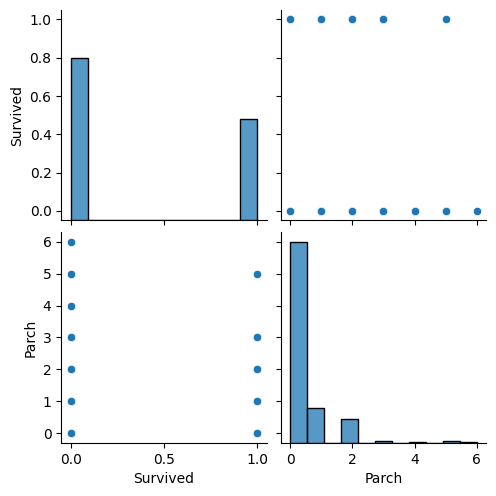

In [ ]:
sns.pairplot(data=df_as)
plt.show()

In [ ]:
df_as[df_as["Survived"]== 1].groupby("Parch").count()

,Survived
Parch,
0,233
1,65
2,40
3,3
5,1


In [12]:
df_as[df_as["Survived"]== 0].groupby("Parch").count()

,Survived
Parch,
0,445
1,53
2,40
3,2
4,4
5,4
6,1


In [ ]:

survival_by_parch = df.groupby('Parch')['Survived'].sum()

print(survival_by_parch)

Parch
0    233
1     65
2     40
3      3
4      0
5      1
6      0
Name: Survived, dtype: int64
